# Libraries and functions

In [1]:
import numpy as np
import diffusion.constrained_bp_d3pm_local as bpd

import diffusion.constrained_bp_d3pm_local as bpd
from diffusion.plot_bp_d3pm_local import (
    plot_loss_error,
    plot_margin_negative_and_peeled_loss,
    plot_loss_decomposition,
    plot_generated_rule_errors,
    plot_message_diagnostics,
)

/home/2a/mb12724/miniconda3/envs/emb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Runs

# L=3

In [2]:
name_save = "diffusion_BP_L5_v1"

In [3]:
lambda_values = np.logspace(np.log10(1.0), np.log10(200.0), 20)

name_save = "bp_d3pm_fig1a_RHM_L5_s2_v16_m3_local.npz"

res = bpd.simulate_local_bp_d3pm_sweep(
    # RHM setting of Fig. 1(a) in Favero et al.
    num_features=16,      # v = visible vocabulary size
    num_classes=16,       # root vocabulary size; same v in the paper setting
    num_synonyms=3,       # m
    tuple_size=2,         # s
    num_layers=5,         # L

    # P is not conceptually relevant for oracle BP, but keep it for dataset construction.
    # test_size controls the Monte Carlo estimate of the denoising test loss.
    train_size=1024,
    test_size=128,

    lambda_values=lambda_values,
    seed_rules=1,
    seed_sample=1,
    seed_noise=1,

    # Uniform D3PM setting: 1000 linear noise levels.
    # The paper states 1000 linear noise levels; the exact beta endpoints are not
    # specified in the text, so these are the standard D3PM/DDPM-style endpoints.
    diffusion_steps=1000,
    beta_start=1e-4,
    beta_end=2e-2,
    beta_schedule="linear",
    num_time_samples_per_sequence=1,

    # BP / evaluation settings
    margin_context="clean",
    batch_size=128,
    device="cpu",   # use cuda if available; cpu will be very slow for L=5

    # Generation = analogue of Fig. 1(a) rule-validity accuracy.
    # The paper uses 1024 generated samples.
    compute_generation=True,
    num_generated=128,
    generation_batch_size=128,
    generation_seed=1,
)

bpd.save_results_npz(res, "./data/BP/" + name_save)

precompute A/B masks:   0%|          | 0/4096 [00:00<?, ?it/s]

lambda sweep: 100%|██████████| 20/20 [05:55<00:00, 17.80s/it]            


PosixPath('data/BP/bp_d3pm_fig1a_RHM_L5_s2_v16_m3_local.npz.npz')

(<Figure size 1200x800 with 4 Axes>,
 array([[<Axes: title={'center': 'total quadratic cost'}, xlabel='local message radius $\\lambda$', ylabel='$\\langle\\sum_e\\|c_e\\|^2\\rangle$'>,
         <Axes: title={'center': 'total L2 sum'}, xlabel='local message radius $\\lambda$', ylabel='$\\langle\\sum_e\\|c_e\\|\\rangle$'>],
        [<Axes: title={'center': 'max local norm'}, xlabel='local message radius $\\lambda$', ylabel='mean max message norm'>,
         <Axes: title={'center': 'fraction of clipped messages'}, xlabel='local message radius $\\lambda$', ylabel='clipped fraction'>]],
       dtype=object))

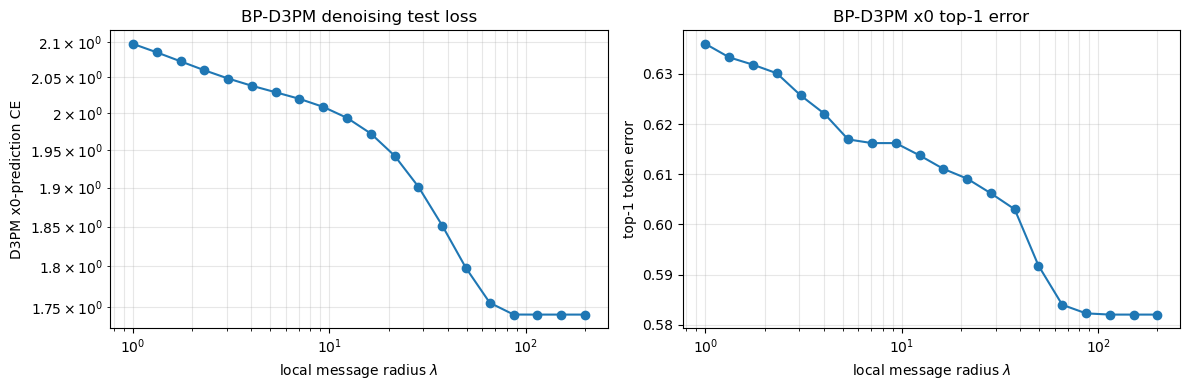

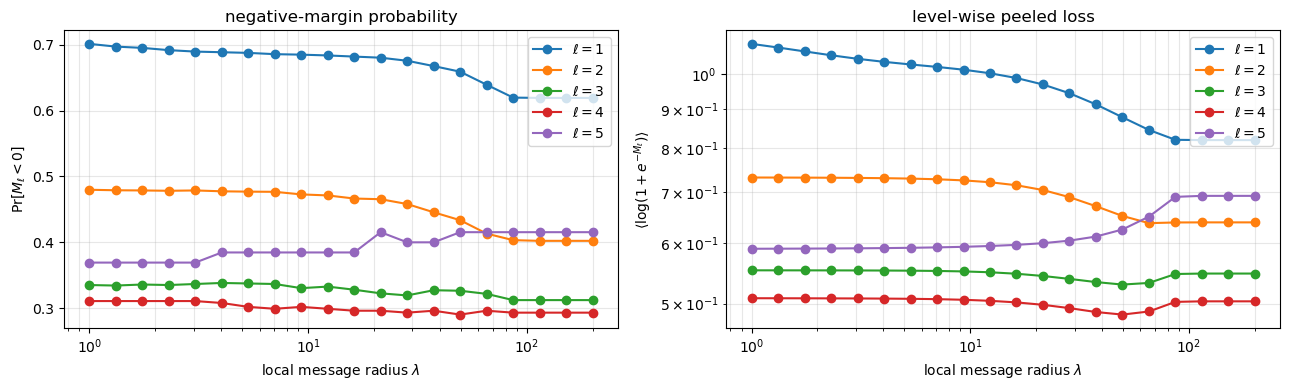

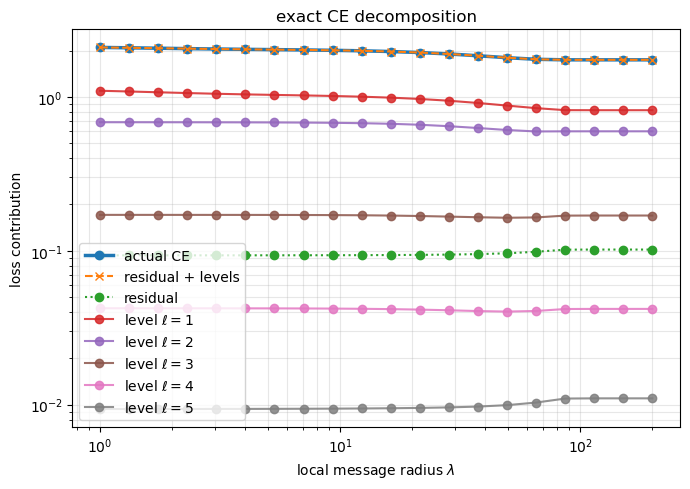

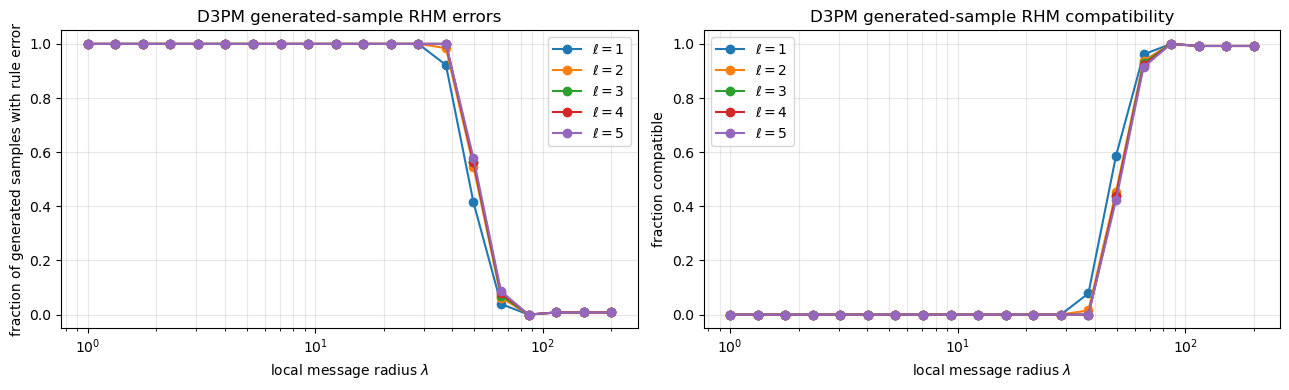

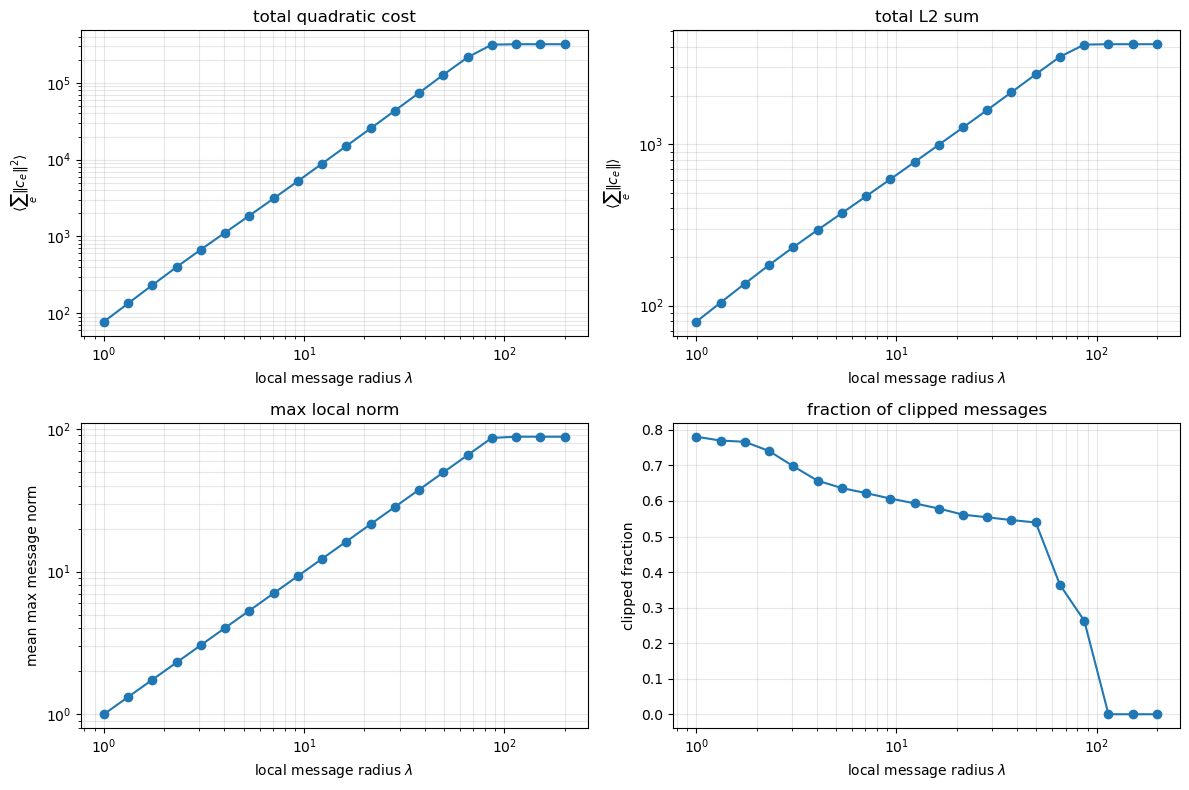

In [4]:
plot_loss_error(res)
plot_margin_negative_and_peeled_loss(res)
plot_loss_decomposition(res)
plot_generated_rule_errors(res)
plot_message_diagnostics(res)

## L=4